In [1]:
import matplotlib.pyplot as plt
import torch

from pi_solvers import sde_lib, solver_lib, utils

torch.manual_seed(42)

In [2]:
edm = solver_lib.get_edm_schedule(25)
edm < 1

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True])

In [3]:
model, encoder = utils.load_edm_checkpoint("../model/edm2-img64-xl-0671088-0.040.pkl")
model = model.to("cuda")

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde_lib.EDMSDE(ode=False).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")

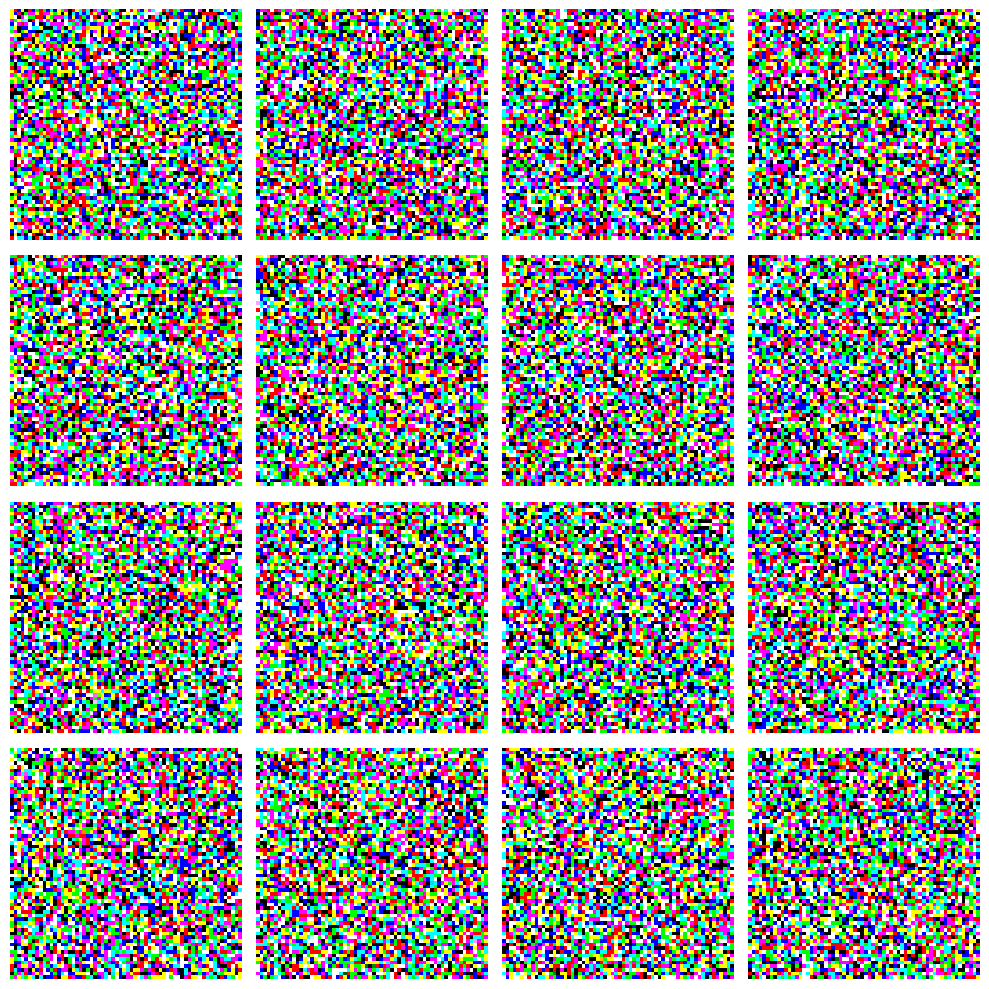

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [23]:
n_steps = 25
rho = 7
# From EDM2 code
# discretisation = solver_lib.get_edm_schedule(n_steps, sigma_min, sigma_max, rho)
# discretisation = solver_lib.get_entropy_schedule(n_steps, entropy_checkpoint="../refs/img64_rescaled_entropic_time.pt")
discretisation = solver_lib.get_pi_schedule(20, 5, "../data/image_testing/pi_2/50NFE_4/data/_t.csv")

In [24]:
discretisation

tensor([8.0000e+01, 3.3188e+01, 1.8424e+01, 1.0780e+01, 6.6736e+00, 4.3042e+00,
        2.8680e+00, 1.9692e+00, 1.3812e+00, 9.8310e-01, 7.1087e-01, 5.2007e-01,
        3.8283e-01, 2.8352e-01, 2.1135e-01, 1.5812e-01, 1.1886e-01, 9.1566e-02,
        7.8032e-02, 7.5576e-02, 5.0000e-02, 2.5413e-02, 1.2013e-02, 5.1904e-03,
        2.0000e-03, 0.0000e+00], dtype=torch.float64)

In [20]:
rsde.reset()

em_solver = solver_lib.HeunSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

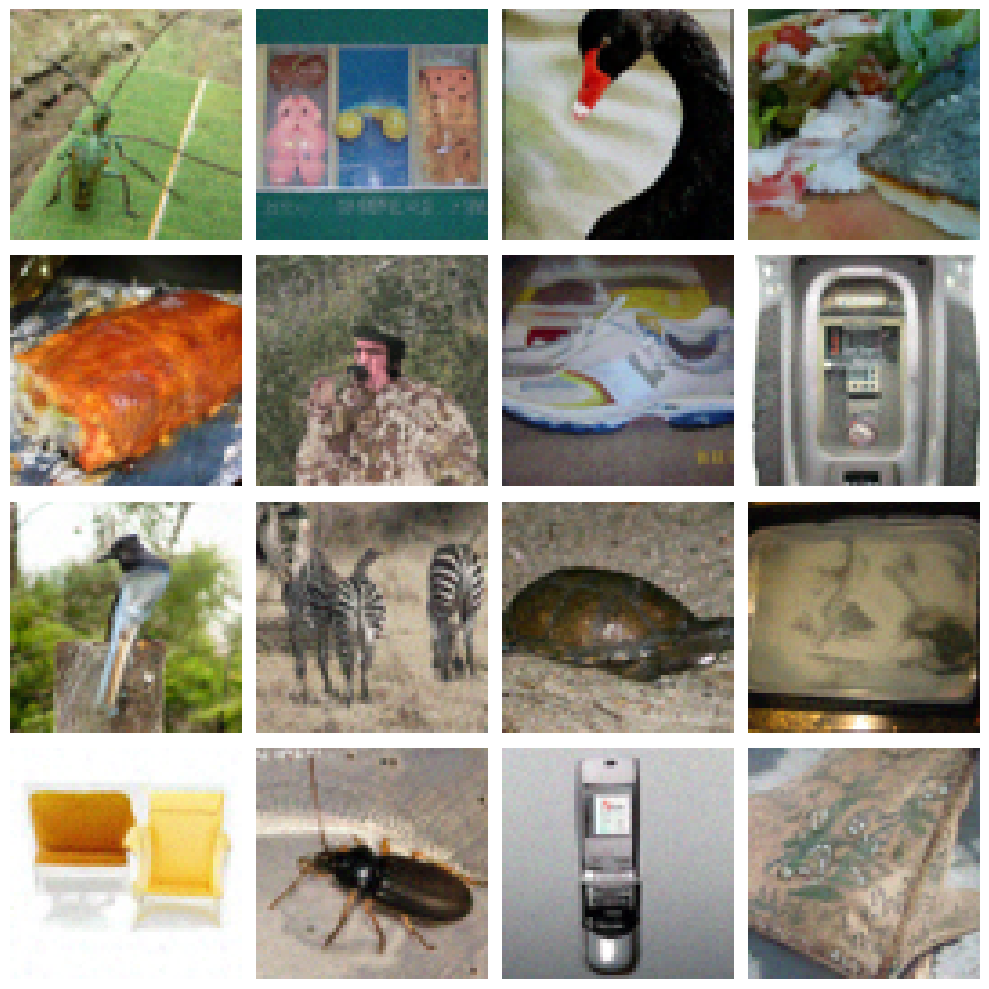

In [21]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [9]:
sigmas = []
sigmas_std = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())

In [31]:
heun_solver = solver_lib.HeunSolver(rsde, torch.tensor([80, 35])).to("cuda")
rsde.ode = True
x_one_ode = heun_solver.solve(noise.clone(), labels)
rsde.ode = False

In [32]:
sigmas = [80]
sigmas_std = [0]

rsde.reset()

pi_solver = solver_lib.PISolver2.create_heun_end_pi_solver(
    rsde,
    ode_threshold=0.05,
    n_ode_steps=5,
    ki=0.3,
    kp=0.1, 
    tau_a=0.01,
    tau_r=107,
    alpha=0.9,
    h_start=14,
    max_decrease=0.2,
    max_increase=5,
    interval=(35, 0.002),
    abs_error=False,
    batch_norm=False
).to("cuda")

x_pi = pi_solver.solve(x_one_ode, labels, callback=pi_callback)

sigma = 21.0 h = -6.248868465423584 error = 0.0676184818148613
sigma = 14.751131057739258 h = -4.366859436035156 error = 0.03649919480085373
sigma = 10.384271621704102 h = -2.8832082748413086 error = 0.03605758771300316
sigma = 7.501062870025635 h = -1.9961705207824707 error = 0.03192615136504173
sigma = 5.504892349243164 h = -1.410217523574829 error = 0.029444962739944458
sigma = 4.094675064086914 h = -1.0154087543487549 error = 0.02751411870121956
sigma = 3.079266309738159 h = -0.7445496320724487 error = 0.025849327445030212
sigma = 2.334716558456421 h = -0.5528315305709839 error = 0.024663373827934265
sigma = 1.7818851470947266 h = -0.4155091643333435 error = 0.02364480495452881
sigma = 1.3663759231567383 h = -0.3153180778026581 error = 0.022840965539216995
sigma = 1.0510578155517578 h = -0.24050641059875488 error = 0.022358262911438942
sigma = 0.8105514049530029 h = -0.184849813580513 error = 0.021817784756422043
sigma = 0.6257016062736511 h = -0.1426824927330017 error = 0.02145523

In [33]:
rsde.nfe / 16

54.25

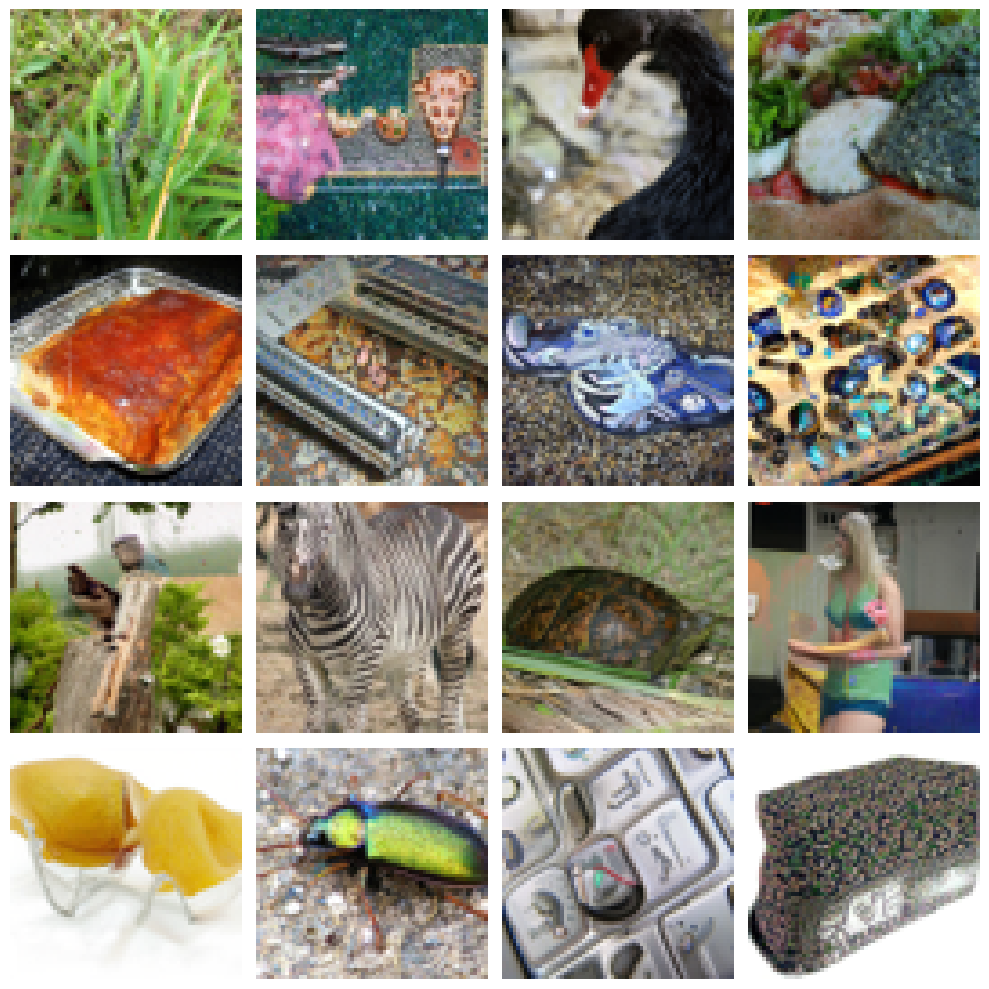

In [34]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [85]:
sigmas = [80]
sigmas_std = [0]

rsde.reset()

ggf_solver = solver_lib.GottaGoFast(
    rsde,
    tau_a=0.006,
    tau_r=20,
    h_start=18,
    r=0.3,
    alpha=0.9,
    interval=(80, 0.002)
).to("cuda")

x_ggf = ggf_solver.solve(noise.clone(), labels, pi_callback)

sigma = 62.0 h = -26.225658416748047 error = 0.20075076818466187
sigma = 62.0 h = -21.471851348876953 error = 1.3709847927093506
sigma = 40.52814483642578 h = -21.55942153930664 error = 0.6944253444671631
sigma = 40.52814483642578 h = -13.792837142944336 error = 3.119969367980957
sigma = 26.73531150817871 h = -14.516824722290039 error = 0.5935636162757874
sigma = 26.73531150817871 h = -9.065549850463867 error = 3.381714105606079
sigma = 17.669761657714844 h = -9.634001731872559 error = 0.5747135877609253
sigma = 17.669761657714844 h = -5.984122276306152 error = 3.4424362182617188
sigma = 11.685638427734375 h = -6.368109226226807 error = 0.5720754265785217
sigma = 11.685638427734375 h = -3.9660511016845703 error = 3.4121041297912598
sigma = 7.719588279724121 h = -4.211529731750488 error = 0.5761725902557373
sigma = 7.719588279724121 h = -2.6281023025512695 error = 3.3905231952667236
sigma = 5.091485977172852 h = -2.78208589553833 error = 0.5822879076004028
sigma = 5.091485977172852 h = 

In [86]:
rsde.nfe / 16

57.75

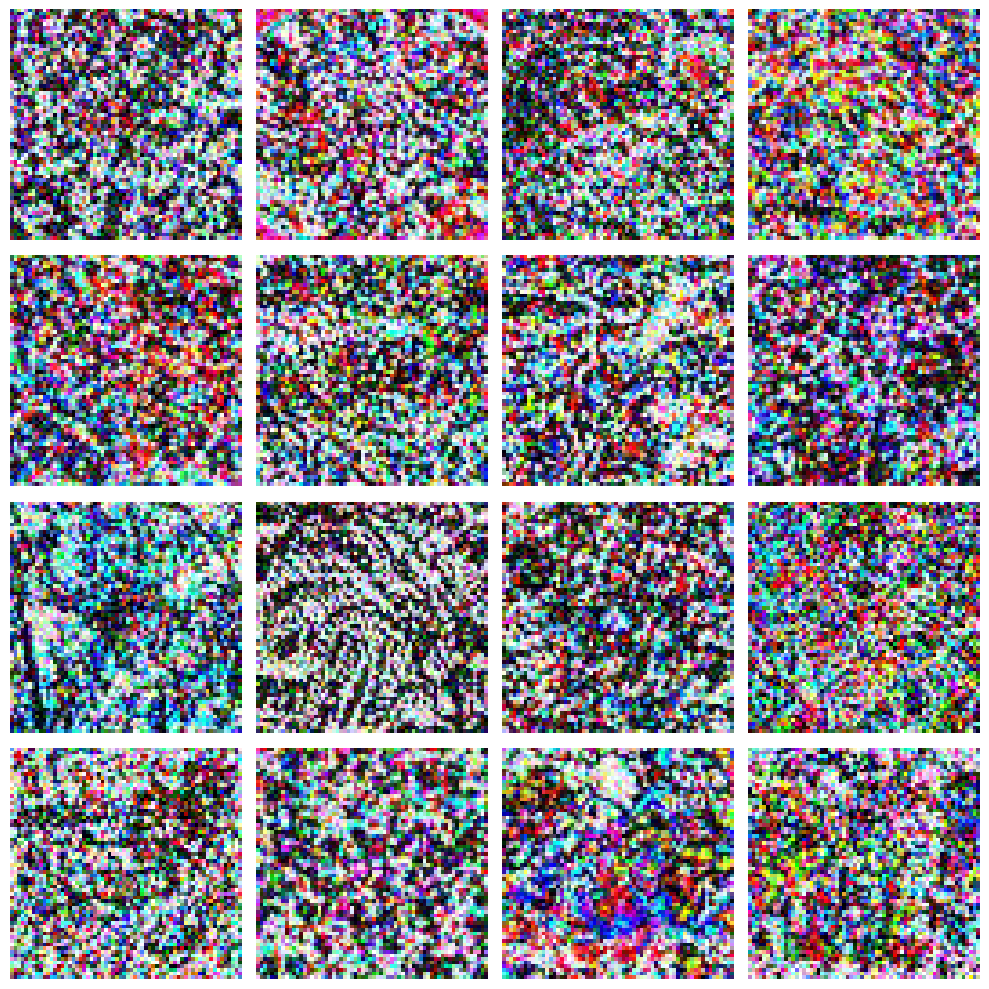

In [87]:
images = encoder.decode(x_ggf).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

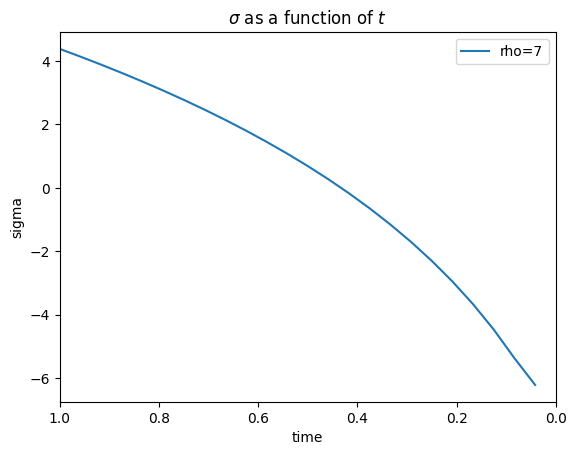

In [9]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas)), label="discovered")

# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) + torch.tensor(sigmas_std)))
# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) - torch.tensor(sigmas_std)))
plt.plot(torch.linspace(1, 0, len(discretisation)), torch.log(discretisation), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")

In [25]:
edm_solver = solver_lib.EDMSolver(discretisation, model, S_churn=40, S_min=0.05, S_max=50, S_noise=1.003).to("cuda")
x_edm = edm_solver.solve(noise.clone(), labels)

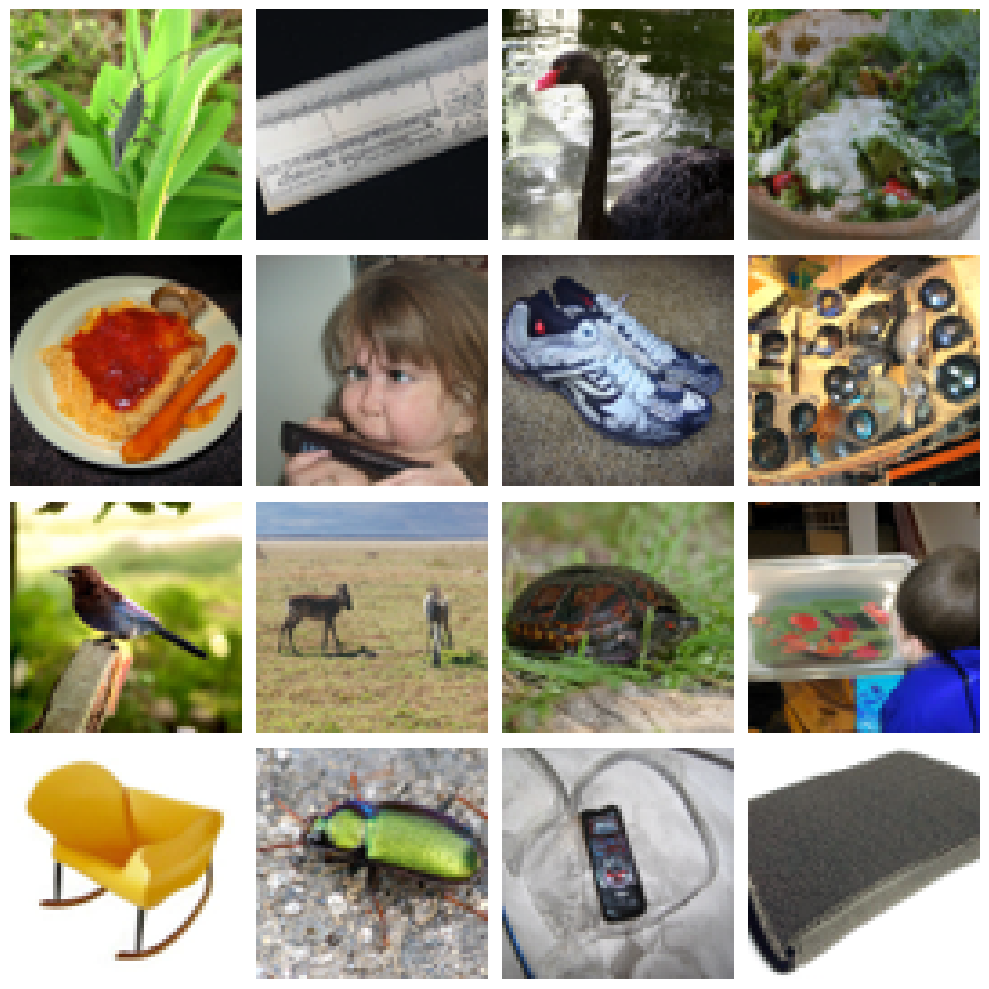

In [26]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())